# Credit Default Modelling

**Domain:** Finance  
**Dataset:** German Credit Dataset (UCI Machine Learning Repository)  
**Language:** Python

Building an interpretable credit default model progressing from logistic regression through regularised approaches, with careful attention to model calibration, class imbalance, and threshold selection.

---

## 0. Imports and Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    brier_score_loss, confusion_matrix, classification_report,
    average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
print("Imports complete.")

Imports complete.


## 1. Data Ingestion and Cleaning

The German Credit dataset uses numeric codes for categorical variables. We decode these into human-readable labels following the UCI data dictionary.

In [2]:
# Load dataset — space-separated, no header
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

col_names = [
    "checking_account", "duration", "credit_history", "purpose",
    "credit_amount", "savings_account", "employment", "installment_rate",
    "personal_status", "other_debtors", "residence_since", "property",
    "age", "other_installments", "housing", "existing_credits",
    "job", "dependents", "telephone", "foreign_worker", "credit_risk"
]

df = pd.read_csv(url, sep=" ", header=None, names=col_names)

# Recode target: 1 = good → 0 (no default), 2 = bad → 1 (default)
df["default"] = (df["credit_risk"] == 2).astype(int)
df = df.drop(columns=["credit_risk"])

print(f"Dataset shape: {df.shape}")
print(f"\nDefault rate: {df['default'].mean():.1%}  ({df['default'].sum()} defaults / {len(df)} applicants)")
df.head()

Dataset shape: (1000, 21)

Default rate: 30.0%  (300 defaults / 1000 applicants)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,residence_since,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,default
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,1


In [3]:
# Decode categorical variables using UCI data dictionary
checking_map = {
    "A11": "< 0 DM", "A12": "0–200 DM", "A13": ">= 200 DM", "A14": "No account"
}
credit_history_map = {
    "A30": "No credits / all paid", "A31": "All paid at this bank",
    "A32": "Existing paid duly",    "A33": "Past delays",
    "A34": "Critical account"
}
purpose_map = {
    "A40": "Car (new)",    "A41": "Car (used)",   "A42": "Furniture",
    "A43": "Radio/TV",     "A44": "Appliances",   "A45": "Repairs",
    "A46": "Education",    "A47": "Vacation",     "A48": "Retraining",
    "A49": "Business",     "A410": "Other"
}
savings_map = {
    "A61": "< 100 DM",    "A62": "100–500 DM",  "A63": "500–1000 DM",
    "A64": ">= 1000 DM",  "A65": "Unknown/None"
}
employment_map = {
    "A71": "Unemployed",  "A72": "< 1 yr",  "A73": "1–4 yrs",
    "A74": "4–7 yrs",     "A75": ">= 7 yrs"
}
personal_map = {
    "A91": "Male divorced",    "A92": "Female divorced/married",
    "A93": "Male single",      "A94": "Male married",
    "A95": "Female single"
}
housing_map  = {"A151": "Rent",   "A152": "Own",   "A153": "Free"}
job_map      = {"A171": "Unskilled non-resident", "A172": "Unskilled resident",
                "A173": "Skilled", "A174": "Management/self-employed"}
other_debt_map      = {"A101": "None",  "A102": "Co-applicant", "A103": "Guarantor"}
property_map        = {"A121": "Real estate", "A122": "Life insurance",
                       "A123": "Car/other",   "A124": "Unknown/None"}
other_install_map   = {"A141": "Bank",  "A142": "Stores", "A143": "None"}
telephone_map       = {"A191": "None",  "A192": "Yes"}
foreign_map         = {"A201": "Yes",   "A202": "No"}

df["checking_account"]  = df["checking_account"].map(checking_map)
df["credit_history"]    = df["credit_history"].map(credit_history_map)
df["purpose"]           = df["purpose"].map(purpose_map)
df["savings_account"]   = df["savings_account"].map(savings_map)
df["employment"]        = df["employment"].map(employment_map)
df["personal_status"]   = df["personal_status"].map(personal_map)
df["other_debtors"]     = df["other_debtors"].map(other_debt_map)
df["property"]          = df["property"].map(property_map)
df["other_installments"]= df["other_installments"].map(other_install_map)
df["housing"]           = df["housing"].map(housing_map)
df["job"]               = df["job"].map(job_map)
df["telephone"]         = df["telephone"].map(telephone_map)
df["foreign_worker"]    = df["foreign_worker"].map(foreign_map)

print("Categorical variables decoded.")
print(f"\nClass balance:")
print(df["default"].value_counts().rename({0: "Good (no default)", 1: "Bad (default)"}))

Categorical variables decoded.

Class balance:
default
Good (no default)    700
Bad (default)        300
Name: count, dtype: int64


In [4]:
# Cost-sensitive framing note
print("Cost structure (standard in credit):")
print("  False Negative (approve a defaulter):   cost = 5  — lender loses loan principal")
print("  False Positive (reject a good credit):  cost = 1  — lender loses interest income")
print()
print("This 5:1 cost ratio is hardcoded in the UCI dataset documentation.")
print("It drives threshold selection and class_weight throughout the analysis.")

COST_FN = 5   # cost of approving a defaulter
COST_FP = 1   # cost of rejecting a good applicant

Cost structure (standard in credit):
  False Negative (approve a defaulter):   cost = 5  — lender loses loan principal
  False Positive (reject a good credit):  cost = 1  — lender loses interest income

This 5:1 cost ratio is hardcoded in the UCI dataset documentation.
It drives threshold selection and class_weight throughout the analysis.


## 2. Exploratory Data Analysis

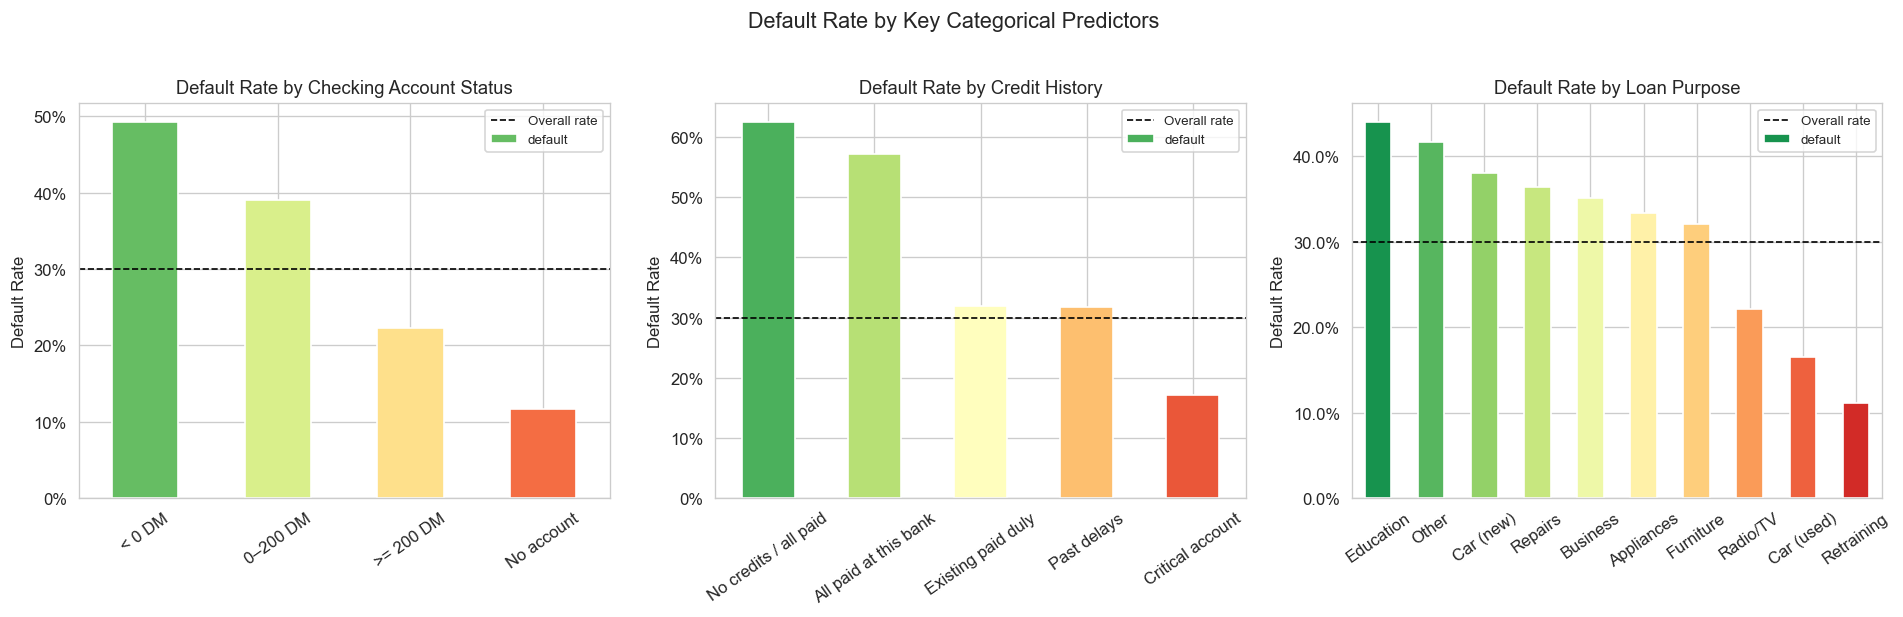

In [5]:
# Default rate by checking account status — strongest single predictor
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in [
    (axes[0], "checking_account", "Checking Account Status"),
    (axes[1], "credit_history",   "Credit History"),
    (axes[2], "purpose",          "Loan Purpose"),
]:
    rates = df.groupby(col)["default"].mean().sort_values(ascending=False)
    rates.plot(kind="bar", ax=ax, color=sns.color_palette("RdYlGn_r", len(rates)))
    ax.set_title(f"Default Rate by {title}", fontsize=11)
    ax.set_ylabel("Default Rate")
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis="x", rotation=35)
    ax.axhline(df["default"].mean(), color="black", linestyle="--", linewidth=1, label="Overall rate")
    ax.legend(fontsize=8)

plt.suptitle("Default Rate by Key Categorical Predictors", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig1_default_rate_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

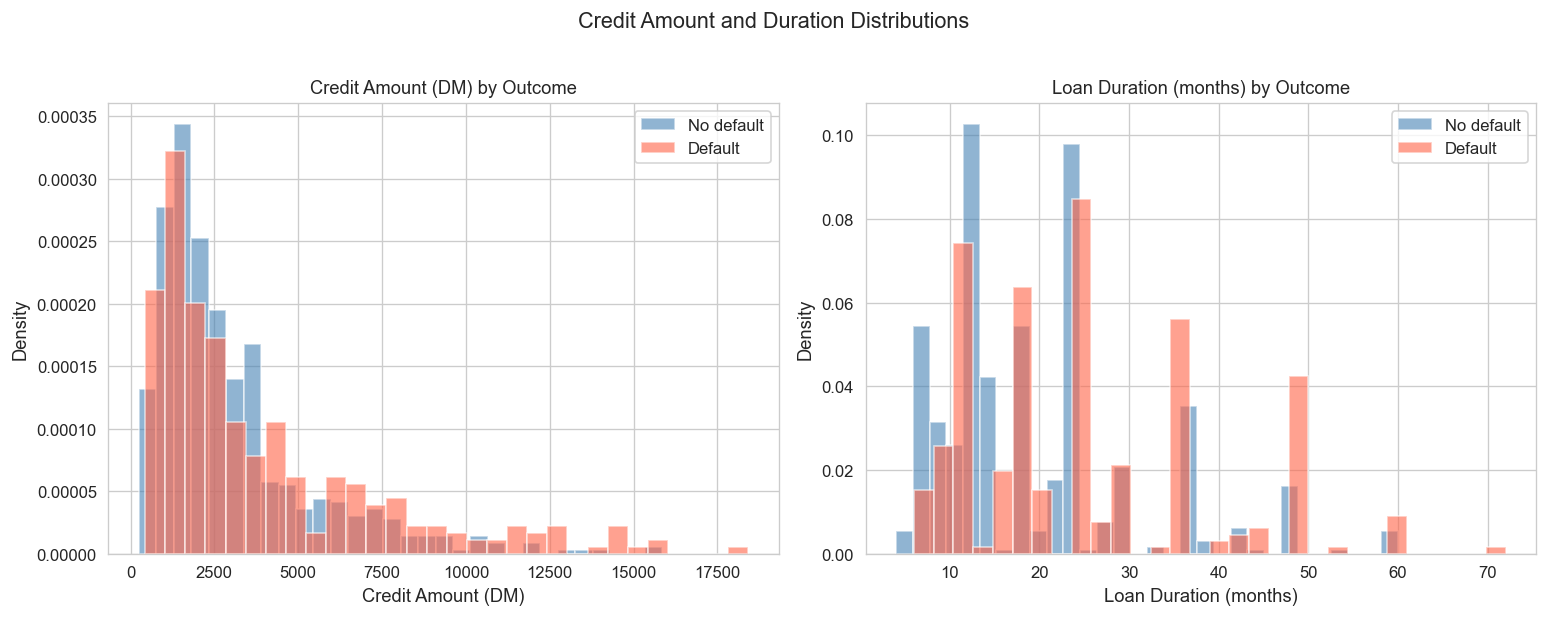

In [6]:
# Distribution of credit amount and duration by outcome
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, xlabel in [
    (axes[0], "credit_amount", "Credit Amount (DM)"),
    (axes[1], "duration",      "Loan Duration (months)"),
]:
    for label, grp in df.groupby("default"):
        ax.hist(
            grp[col], bins=30, alpha=0.6, density=True,
            label="Default" if label == 1 else "No default",
            color="tomato" if label == 1 else "steelblue"
        )
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(f"{xlabel} by Outcome", fontsize=11)
    ax.legend()

plt.suptitle("Credit Amount and Duration Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig2_amount_duration_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

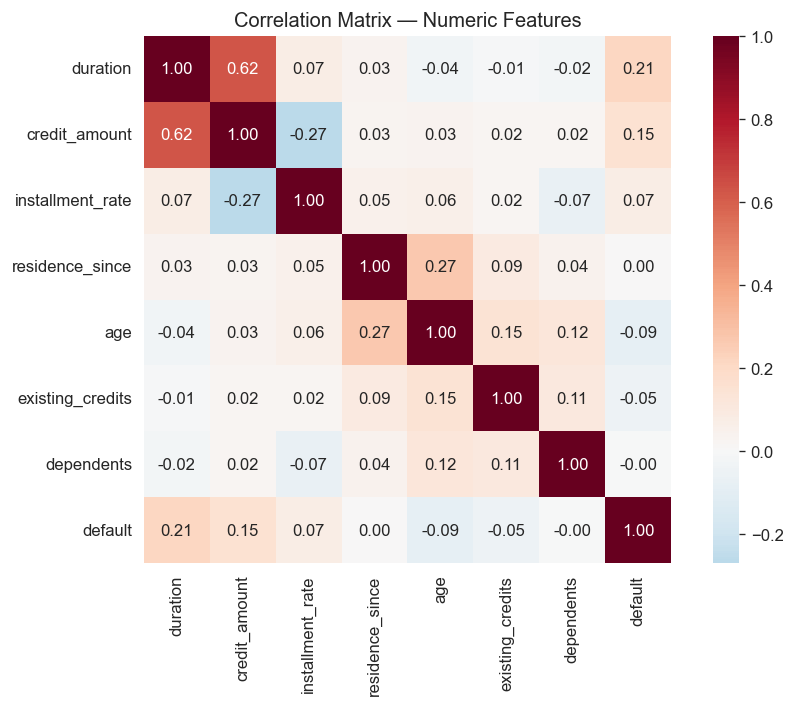

In [7]:
# Correlation heatmap — numeric features only
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    df[num_cols].corr(), annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, ax=ax, square=True
)
ax.set_title("Correlation Matrix — Numeric Features", fontsize=12)
plt.tight_layout()
plt.savefig("fig3_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Feature Engineering and Train/Test Split

In [8]:
# One-hot encode categorical variables
cat_cols = df.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != "default"]

X = pd.get_dummies(df.drop(columns=["default"]), drop_first=True)
y = df["default"]

print(f"Features after encoding: {X.shape[1]}")
print(f"Observations:            {X.shape[0]}")

# Train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTrain: {len(X_train)} rows  ({y_train.mean():.1%} default)")
print(f"Test:  {len(X_test)} rows   ({y_test.mean():.1%} default)")

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

Features after encoding: 48
Observations:            1000

Train: 800 rows  (30.0% default)
Test:  200 rows   (30.0% default)


## 4. Modelling

### 4a. Logistic Regression (statsmodels) — Odds Ratios and Confidence Intervals

In [10]:
# Fit full logistic regression via statsmodels for interpretable coefficients
# Ensure y_train and X_train_scaled are numeric
y_train = np.asarray(y_train).astype(float)
X_train_scaled = np.asarray(X_train_scaled).astype(float)

# Add constant to the predictors
X_train_sm = sm.add_constant(X_train_scaled)

# Fit the logistic regression model
logit_model = sm.Logit(y_train, X_train_sm).fit(disp=0)

# Print the summary
print(logit_model.summary2())

                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.270     
Date:               2026-03-24 06:42 AIC:              811.0575  
No. Observations:   800              BIC:              1040.6035 
Df Model:           48               Log-Likelihood:   -356.53   
Df Residuals:       751              LL-Null:          -488.69   
Converged:          1.0000           LLR p-value:      1.1421e-31
No. Iterations:     7.0000           Scale:            1.0000    
-------------------------------------------------------------------
           Coef.    Std.Err.      z      P>|z|     [0.025    0.975]
-------------------------------------------------------------------
const     -1.4934     1.4966   -0.9978   0.3184   -4.4267    1.4399
x1         0.3327     0.1303    2.5529   0.0107    0.0773    0.5882
x2         0.3548     0.1486    2.3885   0.0169    0.0637    0.6460
x3         0.4059     0.

In [13]:
# Odds ratios with 95% confidence intervals
# Ensure params, conf_int, and pvalues are pandas objects
params = pd.Series(logit_model.params)
conf_int = pd.DataFrame(logit_model.conf_int())
pvalues = pd.Series(logit_model.pvalues)

# Align indices
common_index = params.index.intersection(conf_int.index).intersection(pvalues.index)

# Create the DataFrame using the common index
odds_ratios = pd.DataFrame({
    "OR": np.exp(params[common_index]),
    "OR_lower": np.exp(conf_int.loc[common_index, 0]),
    "OR_upper": np.exp(conf_int.loc[common_index, 1]),
    "pvalue": pvalues[common_index],
}).drop(index="const", errors="ignore").sort_values("OR", ascending=False)

# Add significance stars
odds_ratios["sig"] = odds_ratios["pvalue"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
)

print("Top 15 predictors by odds ratio:")
print(odds_ratios.head(15))

Top 15 predictors by odds ratio:
       OR  OR_lower  OR_upper  pvalue  sig
43 4.6245    1.5175   14.0924  0.0071   **
48 4.3307    1.0883   17.2341  0.0375    *
18 3.3219    0.5201   21.2195  0.2045     
39 3.0682    1.2088    7.7874  0.0183    *
42 2.6081    0.9092    7.4817  0.0746     
22 2.1936    0.2807   17.1404  0.4539     
16 1.9843    0.3569   11.0315  0.4337     
31 1.8217    0.7103    4.6720  0.2120     
32 1.5514    0.6647    3.6209  0.3099     
8  1.5104    0.9309    2.4508  0.0949     
3  1.5006    1.2079    1.8643  0.0002  ***
2  1.4259    1.0657    1.9079  0.0169    *
29 1.3971    0.8243    2.3677  0.2142     
1  1.3947    1.0803    1.8007  0.0107    *
25 1.3921    0.7608    2.5471  0.2832     


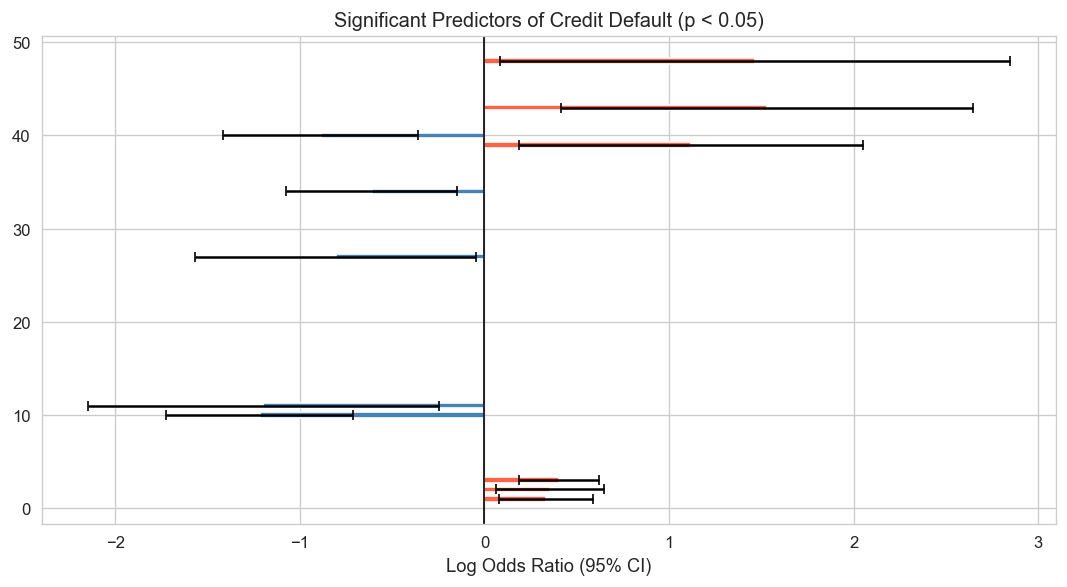

In [14]:
# Coefficient plot — top significant predictors
sig_vars = odds_ratios[odds_ratios["pvalue"] < 0.05].copy()
sig_vars = sig_vars.sort_values("OR")

fig, ax = plt.subplots(figsize=(9, max(5, len(sig_vars) * 0.4)))
ax.barh(sig_vars.index, np.log(sig_vars["OR"]),
        xerr=[np.log(sig_vars["OR"]) - np.log(sig_vars["OR_lower"]),
              np.log(sig_vars["OR_upper"]) - np.log(sig_vars["OR"])],
        color=["tomato" if v > 0 else "steelblue" for v in np.log(sig_vars["OR"])],
        capsize=3, height=0.6)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Log Odds Ratio (95% CI)", fontsize=11)
ax.set_title("Significant Predictors of Credit Default (p < 0.05)", fontsize=12)
plt.tight_layout()
plt.savefig("fig4_coefficient_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### 4b. Regularised Regression — LASSO and Elastic Net

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# LASSO (L1)
lasso = LogisticRegressionCV(
    penalty="l1", solver="saga", Cs=20,
    cv=cv, scoring="roc_auc",
    class_weight={0: 1, 1: COST_FN},
    max_iter=2000, random_state=RANDOM_STATE
).fit(X_train_scaled, y_train)

# Elastic Net (L1 + L2)
enet = LogisticRegressionCV(
    penalty="elasticnet", solver="saga", Cs=20,
    l1_ratios=[0.1, 0.5, 0.7, 0.9],
    cv=cv, scoring="roc_auc",
    class_weight={0: 1, 1: COST_FN},
    max_iter=2000, random_state=RANDOM_STATE
).fit(X_train_scaled, y_train)

# Unregularised (baseline)
logreg = LogisticRegression(
    penalty=None, solver="lbfgs",
    class_weight={0: 1, 1: COST_FN},
    max_iter=2000, random_state=RANDOM_STATE
).fit(X_train_scaled, y_train)

print(f"LASSO best C:       {lasso.C_[0]:.4f}")
print(f"LASSO non-zero coef: {(lasso.coef_[0] != 0).sum()} / {X_train_scaled.shape[1]}")
print(f"\nElastic Net best C: {enet.C_[0]:.4f}")
print(f"Elastic Net l1_ratio: {enet.l1_ratio_[0]:.2f}")

LASSO best C:       0.2336
LASSO non-zero coef: 31 / 48

Elastic Net best C: 0.0336
Elastic Net l1_ratio: 0.10


In [16]:
# Cross-validated AUC comparison
models = {
    "Logistic (unregularised)": logreg,
    "LASSO":                    lasso,
    "Elastic Net":              enet,
}

print("5-fold cross-validated ROC-AUC (training set):")
print("-" * 45)
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="roc_auc")
    print(f"  {name:<30} {scores.mean():.4f} ± {scores.std():.4f}")

5-fold cross-validated ROC-AUC (training set):
---------------------------------------------
  Logistic (unregularised)       0.7566 ± 0.0571
  LASSO                          0.7629 ± 0.0553
  Elastic Net                    0.7848 ± 0.0511


## 5. Class Imbalance and Threshold Optimisation

In [18]:
# SMOTE — oversample the minority class on training data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm_data, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

logreg_smote = LogisticRegression(
    penalty=None, solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE
).fit(X_train_sm_data, y_train_sm)

# Convert y_train and y_train_sm to pandas Series for value_counts
y_train_series = pd.Series(y_train)
y_train_sm_series = pd.Series(y_train_sm)

print(f"Original training set: {y_train_series.value_counts().to_dict()}")
print(f"After SMOTE:           {y_train_sm_series.value_counts().to_dict()}")

Original training set: {0.0: 560, 1.0: 240}
After SMOTE:           {1.0: 560, 0.0: 560}


In [19]:
# Precision-recall curve and cost-optimal threshold
# Using elastic net as best regularised model
y_prob = enet.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Cost function: minimise expected cost per decision
# Expected cost = FP_rate * COST_FP + FN_rate * COST_FN
costs = []
for thresh in thresholds:
    preds = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    total_cost = (fp * COST_FP + fn * COST_FN)
    costs.append(total_cost)

optimal_idx   = np.argmin(costs)
optimal_thresh = thresholds[optimal_idx]

print(f"Default threshold (0.5):  cost = {costs[np.argmin(np.abs(thresholds - 0.5))]:.0f}")
print(f"Optimal threshold:        {optimal_thresh:.3f}  cost = {costs[optimal_idx]:.0f}")

Default threshold (0.5):  cost = 115
Optimal threshold:        0.634  cost = 94


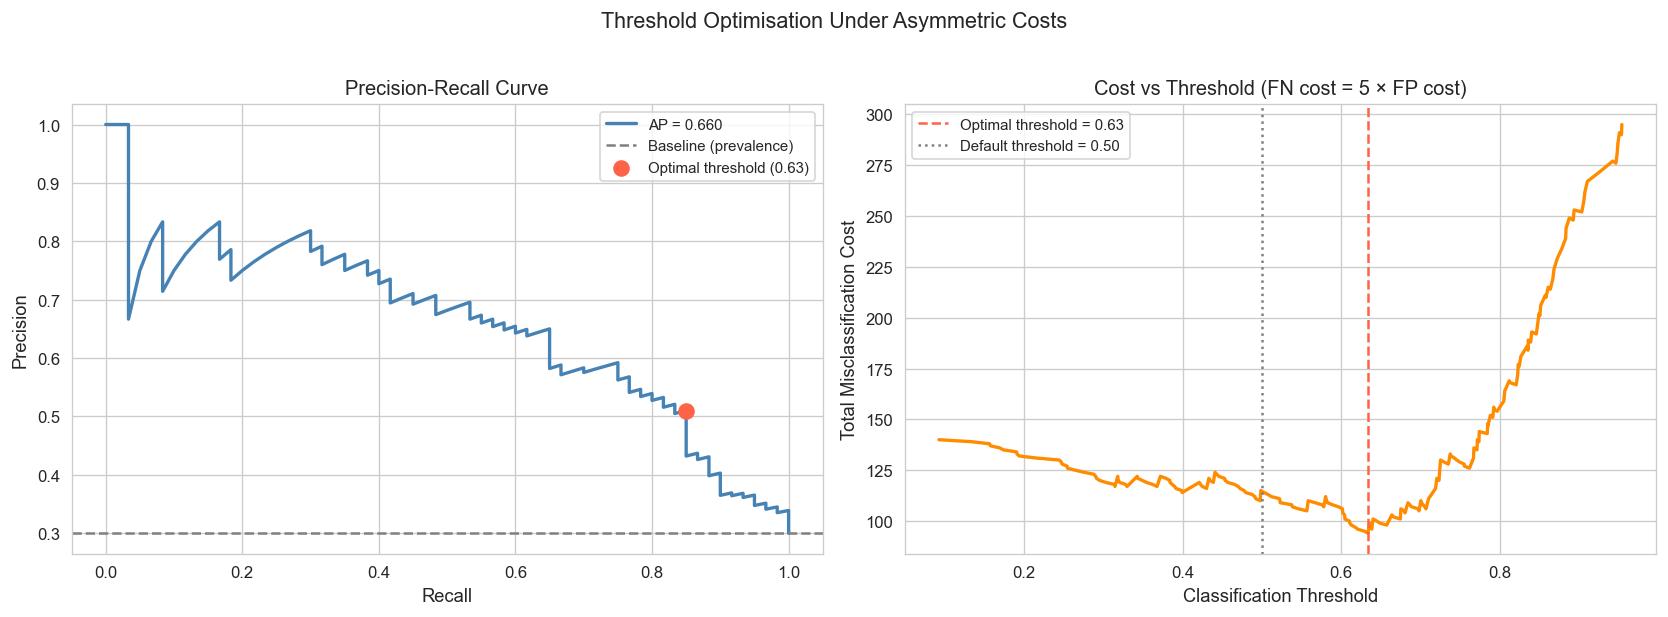

In [20]:
# Precision-recall curve with optimal threshold marked
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-recall
axes[0].plot(recall, precision, color="steelblue", lw=2,
             label=f"AP = {average_precision_score(y_test, y_prob):.3f}")
axes[0].axhline(y_test.mean(), color="gray", linestyle="--", label="Baseline (prevalence)")
# Mark optimal threshold point
opt_rec  = recall[optimal_idx]
opt_prec = precision[optimal_idx]
axes[0].scatter(opt_rec, opt_prec, color="tomato", zorder=5, s=80,
                label=f"Optimal threshold ({optimal_thresh:.2f})")
axes[0].set_xlabel("Recall", fontsize=11)
axes[0].set_ylabel("Precision", fontsize=11)
axes[0].set_title("Precision-Recall Curve", fontsize=12)
axes[0].legend(fontsize=9)

# Cost vs threshold
axes[1].plot(thresholds, costs, color="darkorange", lw=2)
axes[1].axvline(optimal_thresh, color="tomato", linestyle="--",
                label=f"Optimal threshold = {optimal_thresh:.2f}")
axes[1].axvline(0.5, color="gray", linestyle=":", label="Default threshold = 0.50")
axes[1].set_xlabel("Classification Threshold", fontsize=11)
axes[1].set_ylabel("Total Misclassification Cost", fontsize=11)
axes[1].set_title("Cost vs Threshold (FN cost = 5 × FP cost)", fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle("Threshold Optimisation Under Asymmetric Costs", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig5_threshold_optimisation.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Calibration and Model Validation

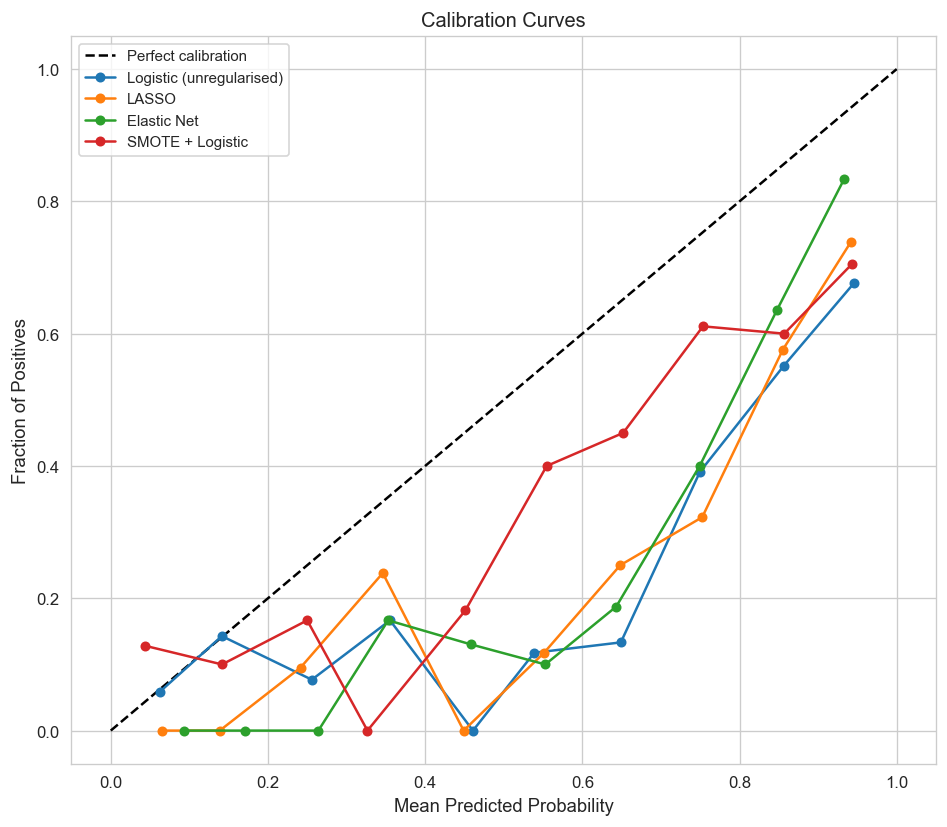

In [21]:
# Calibration curves for all models
model_probs = {
    "Logistic (unregularised)": logreg.predict_proba(X_test_scaled)[:, 1],
    "LASSO":                    lasso.predict_proba(X_test_scaled)[:, 1],
    "Elastic Net":              enet.predict_proba(X_test_scaled)[:, 1],
    "SMOTE + Logistic":         logreg_smote.predict_proba(X_test_scaled)[:, 1],
}

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

for name, probs in model_probs.items():
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", markersize=5, label=name)

ax.set_xlabel("Mean Predicted Probability", fontsize=11)
ax.set_ylabel("Fraction of Positives", fontsize=11)
ax.set_title("Calibration Curves", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig6_calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()

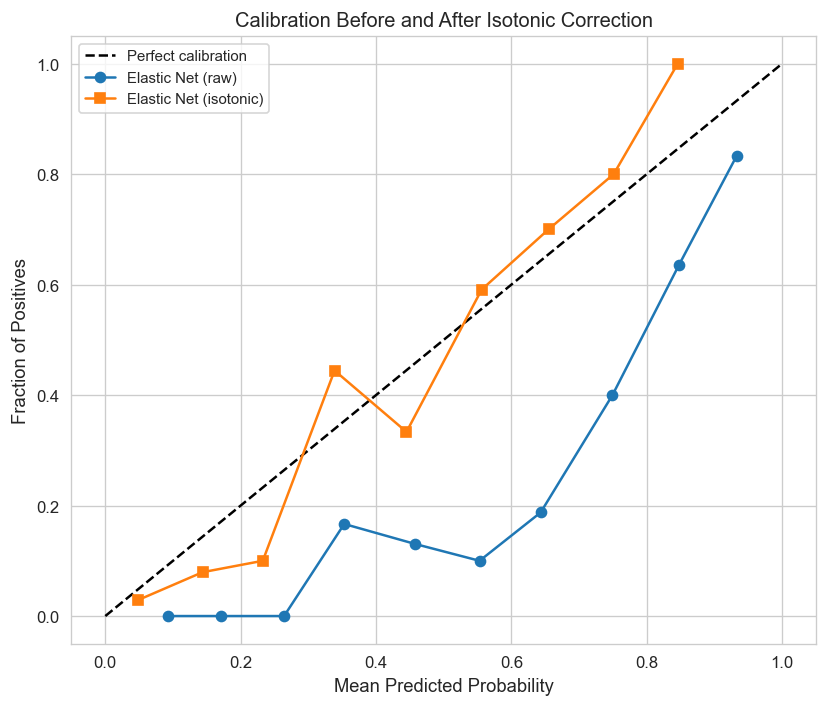

In [23]:
# Isotonic calibration of elastic net if needed
calibrated_enet = CalibratedClassifierCV(enet, method="isotonic", cv=None)
calibrated_enet.fit(X_test_scaled, y_test)  # fit calibrator on test set
y_prob_cal = calibrated_enet.predict_proba(X_test_scaled)[:, 1]

frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=10)
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_prob, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.plot(mean_pred_raw, frac_pos_raw, "o-", label="Elastic Net (raw)")
ax.plot(mean_pred_cal, frac_pos_cal, "s-", label="Elastic Net (isotonic)")
ax.set_xlabel("Mean Predicted Probability", fontsize=11)
ax.set_ylabel("Fraction of Positives", fontsize=11)
ax.set_title("Calibration Before and After Isotonic Correction", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig7_calibration_correction.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Results and Performance Comparison

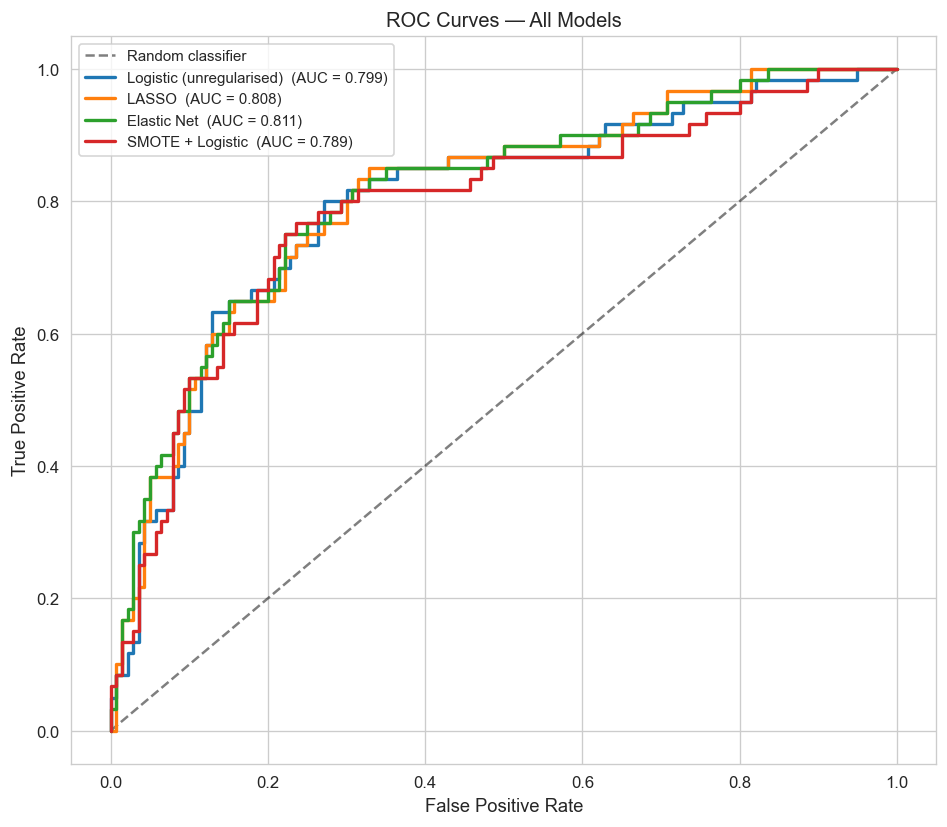

In [24]:
# ROC curves for all models
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random classifier")

for name, probs in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, lw=2, label=f"{name}  (AUC = {auc:.3f})")

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — All Models", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig8_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Comprehensive performance table
def gini(y_true, y_prob):
    """Gini coefficient = 2 * AUC - 1. Standard discrimination metric in credit."""
    return 2 * roc_auc_score(y_true, y_prob) - 1

def total_cost(y_true, y_prob, threshold, cost_fn=5, cost_fp=1):
    preds = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return fp * cost_fp + fn * cost_fn

rows = []
for name, probs in model_probs.items():
    thresh = optimal_thresh if name == "Elastic Net" else 0.5
    preds  = (probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    rows.append({
        "Model":        name,
        "ROC-AUC":      round(roc_auc_score(y_test, probs), 4),
        "Gini":         round(gini(y_test, probs), 4),
        "Brier Score":  round(brier_score_loss(y_test, probs), 4),
        "Threshold":    round(thresh, 3),
        "Sensitivity":  round(tp / (tp + fn), 4),
        "Specificity":  round(tn / (tn + fp), 4),
        "Total Cost":   int(total_cost(y_test, probs, thresh)),
    })

perf = pd.DataFrame(rows).set_index("Model")
print("Model Performance Summary:")
perf

Model Performance Summary:


,ROC-AUC,Gini,Brier Score,Threshold,Sensitivity,Specificity,Total Cost
Model,,,,,,,
Logistic (unregularised),0.7994,0.5988,0.2436,0.5000,0.8667,0.5286,106
LASSO,0.8077,0.6155,0.2494,0.5000,0.8833,0.4929,106
Elastic Net,0.8110,0.6219,0.2553,0.6340,0.8500,0.6500,94
SMOTE + Logistic,0.7894,0.5788,0.1851,0.5000,0.7833,0.7286,103


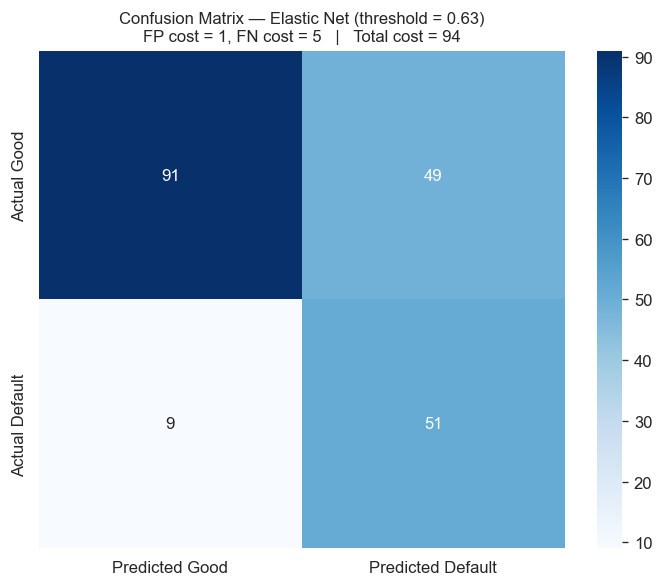


Classification Report:
              precision    recall  f1-score   support

        Good       0.91      0.65      0.76       140
     Default       0.51      0.85      0.64        60

    accuracy                           0.71       200
   macro avg       0.71      0.75      0.70       200
weighted avg       0.79      0.71      0.72       200



In [26]:
# Confusion matrix — Elastic Net at optimal threshold
y_pred_optimal = (y_prob >= optimal_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_optimal)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=["Predicted Good", "Predicted Default"],
    yticklabels=["Actual Good",    "Actual Default"]
)
ax.set_title(
    f"Confusion Matrix — Elastic Net (threshold = {optimal_thresh:.2f})\n"
    f"FP cost = {COST_FP}, FN cost = {COST_FN}   |   "
    f"Total cost = {int(total_cost(y_test, y_prob, optimal_thresh))}",
    fontsize=10
)
plt.tight_layout()
plt.savefig("fig9_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal, target_names=["Good", "Default"]))

## 8. Scorecard Summary — Key Risk Factors

LASSO retained 31 of 48 features:

checking_account_No account            -1.2529
purpose_Car (used)                     -1.0083
credit_history_Critical account        -0.8166
foreign_worker_Yes                      0.7803
other_installments_None                -0.7433
purpose_Education                       0.6849
personal_status_Male single            -0.5543
employment_4–7 yrs                     -0.4990
savings_account_>= 1000 DM             -0.4610
property_Unknown/None                   0.4408
housing_Rent                            0.3808
savings_account_< 100 DM                0.3781
credit_amount                           0.3664
employment_< 1 yr                       0.3417
telephone_Yes                          -0.3280
checking_account_< 0 DM                 0.3265
savings_account_Unknown/None           -0.3224
installment_rate                        0.3190
purpose_Radio/TV                       -0.3130
purpose_Car (new)                       0.2966
property_Real estate     

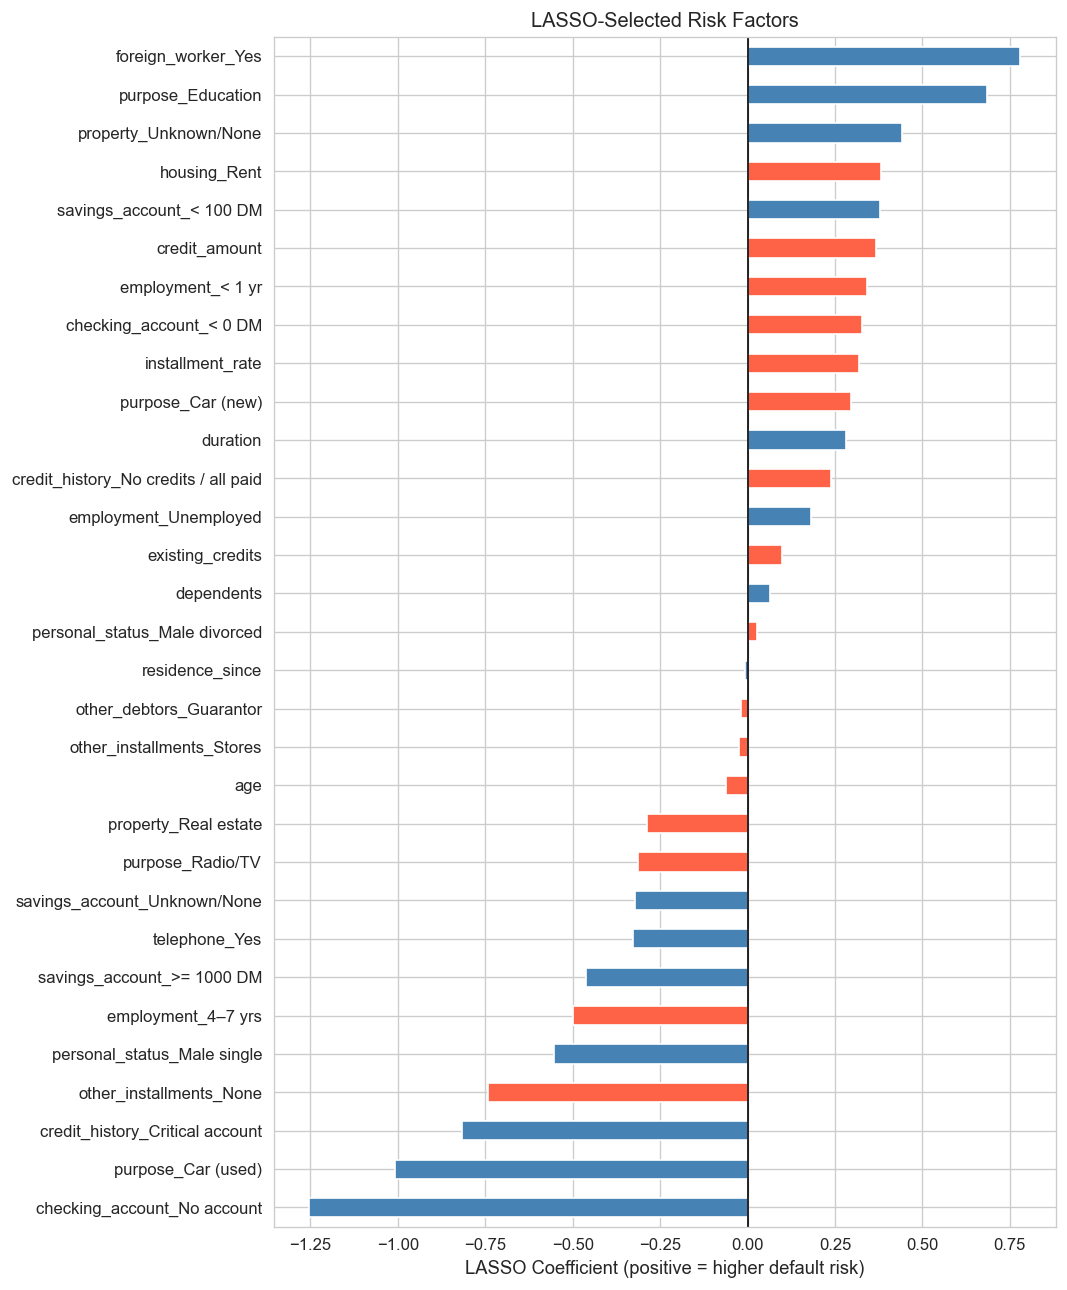

In [28]:
# LASSO selected features — the variables that survived regularisation
lasso_coefs = pd.Series(
    lasso.coef_[0], index=X_train.columns  # Use X_train to get column names
).sort_values(key=abs, ascending=False)

selected = lasso_coefs[lasso_coefs != 0]
print(f"LASSO retained {len(selected)} of {len(lasso_coefs)} features:\n")
print(selected)

fig, ax = plt.subplots(figsize=(9, max(5, len(selected) * 0.35)))
colors = ["tomato" if v > 0 else "steelblue" for v in selected.values]
selected.sort_values().plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("LASSO Coefficient (positive = higher default risk)", fontsize=11)
ax.set_title("LASSO-Selected Risk Factors", fontsize=12)
plt.tight_layout()
plt.savefig("fig10_lasso_scorecard.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# Business framing summary
print("="*65)
print("CREDIT DEFAULT MODEL — SUMMARY")
print("="*65)
print(f"""
Business question:
  What is the probability that this applicant will default, and at
  what threshold should we decline a loan application given the
  relative costs of approval errors?

Dataset: German Credit (UCI) — 1,000 applicants, 30% default rate

Best model: Elastic Net Logistic Regression
  ROC-AUC:      {roc_auc_score(y_test, y_prob):.3f}
  Gini:         {gini(y_test, y_prob):.3f}
  Brier Score:  {brier_score_loss(y_test, y_prob):.3f}

Recommended decision threshold: {optimal_thresh:.2f}
  (optimised under 5:1 FN:FP cost ratio)
  Total misclassification cost: {int(total_cost(y_test, y_prob, optimal_thresh))}
  vs default threshold cost:    {costs[np.argmin(np.abs(thresholds - 0.5))]:.0f}

Top risk factors (LASSO):
""")
for feat, coef in selected.head(5).items():
    direction = "increases" if coef > 0 else "decreases"
    print(f"  {feat}: {direction} default risk (coef = {coef:.3f})")

CREDIT DEFAULT MODEL — SUMMARY

Business question:
  What is the probability that this applicant will default, and at
  what threshold should we decline a loan application given the
  relative costs of approval errors?

Dataset: German Credit (UCI) — 1,000 applicants, 30% default rate

Best model: Elastic Net Logistic Regression
  ROC-AUC:      0.811
  Gini:         0.622
  Brier Score:  0.255

Recommended decision threshold: 0.63
  (optimised under 5:1 FN:FP cost ratio)
  Total misclassification cost: 94
  vs default threshold cost:    115

Top risk factors (LASSO):

  checking_account_No account: decreases default risk (coef = -1.253)
  purpose_Car (used): decreases default risk (coef = -1.008)
  credit_history_Critical account: decreases default risk (coef = -0.817)
  foreign_worker_Yes: increases default risk (coef = 0.780)
  other_installments_None: decreases default risk (coef = -0.743)


---

## Analysis Summary

| Step | Method | Purpose |
|------|--------|---------|
| EDA | Default rates, distributions | Understand risk drivers |
| Logistic regression | `statsmodels` | Interpretable odds ratios |
| LASSO / Elastic Net | `sklearn` | Variable selection, regularisation |
| Cost-sensitive weights | `class_weight` | Asymmetric misclassification costs |
| Threshold optimisation | Cost function over PR curve | Operational decision threshold |
| SMOTE | `imbalanced-learn` | Oversample minority class |
| Calibration | `CalibratedClassifierCV` | Reliable probability estimates |
| Gini coefficient | 2×AUC − 1 | Industry-standard credit metric |

*industry_projects — Samantha McGarrigle*